In [1]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, r2_score
import pandas as pd
import numpy as np
import seaborn as sns
from functions_plot import *

In [2]:
df = pd.read_csv(
    "resultados simplest.txt",
    sep=r"\s+",
    engine="python"
)

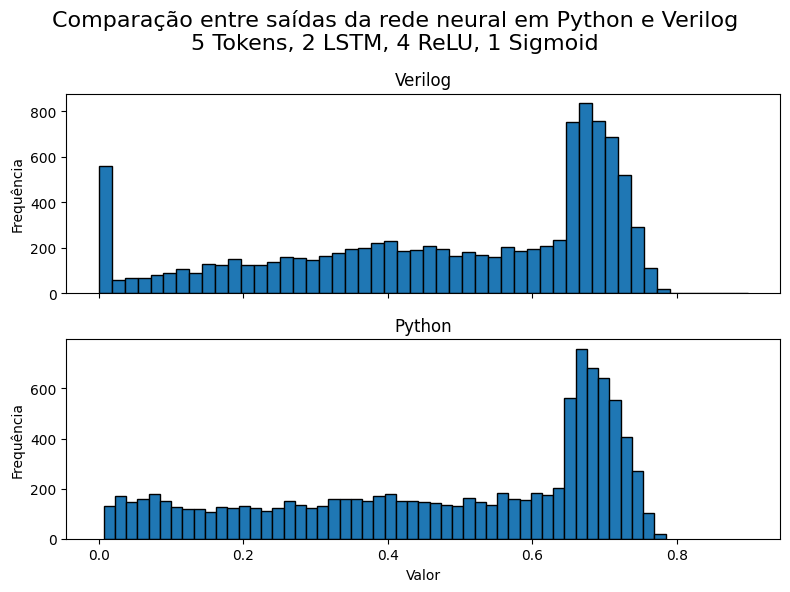

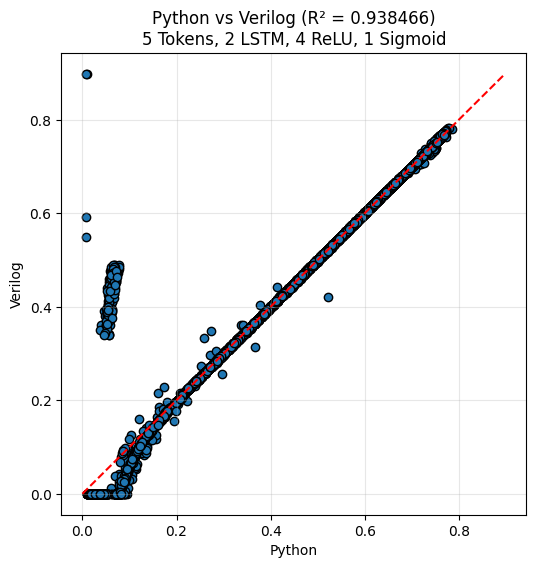

R² = 0.938466
Acurácia Verilog: 0.7103
Acurácia Python : 0.7107


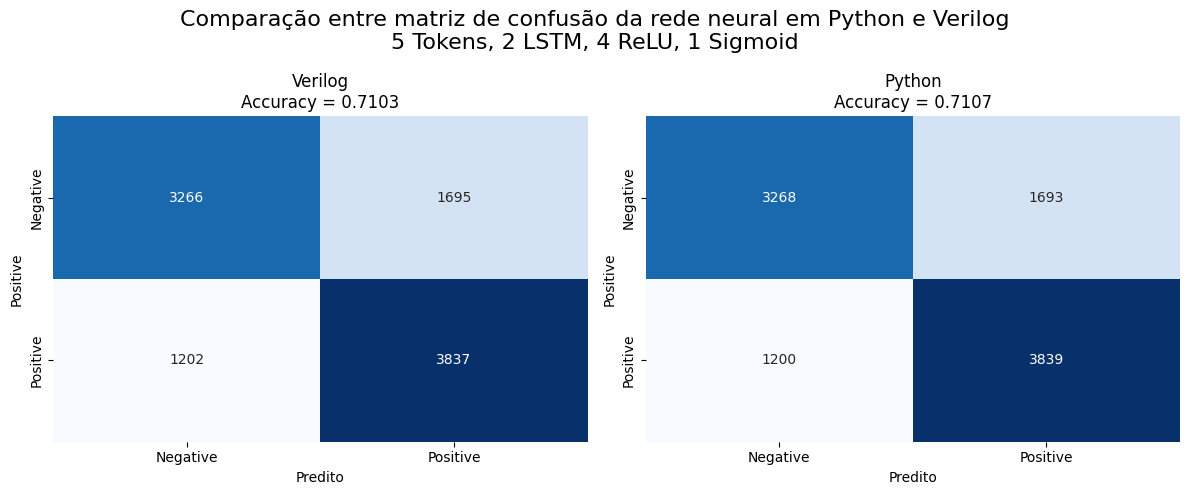

In [3]:
verilog = df['Verilog']
python = df['Python']
ground_truth = df['GroundTruth']

architecture = "5 Tokens, 2 LSTM, 4 ReLU, 1 Sigmoid"

plot_histograms(
    verilog,
    python,
    architecture,
    "comparacao_modelo_simplest_histograms.png"
)

r2_simplest = plot_r2(
    verilog,
    python,
    architecture,
    "comparacao_modelo_simplest_r2_scatter.png"
)

acc_verilog_simplest, acc_python_simplest = plot_confusion_matrix(
    verilog,
    python,
    ground_truth,
    architecture,
    "comparacao_modelo_simplest_cm.png"
)

In [4]:
data_gls=pd.read_csv("resultados simplest gate level.txt", sep=r"\s+")

In [5]:
data_gls

,Verilog,Python,GroundTruth
0,0.342061,0.052015,1
1,0.662598,0.662405,1
2,0.637874,0.636492,0
3,0.769441,0.763880,1
4,0.441687,0.442537,0
...,...,...,...
7776,0.244322,0.245999,1
7777,0.692596,0.692597,1
7778,0.695957,0.695761,1
7779,0.283408,0.283268,0


In [6]:
verilog_gls = data_gls['Verilog']

In [7]:
num_gls = len(verilog_gls)

In [8]:
verilog_gls[:10]

0    0.342061
1    0.662598
2    0.637874
3    0.769441
4    0.441687
5    0.744849
6    0.707432
7    0.225278
8    0.665744
9    0.429331
Name: Verilog, dtype: float64

In [9]:
verilog[:10]

0    0.342061
1    0.662598
2    0.637874
3    0.769441
4    0.441687
5    0.744849
6    0.707432
7    0.225278
8    0.665744
9    0.429331
Name: Verilog, dtype: float64

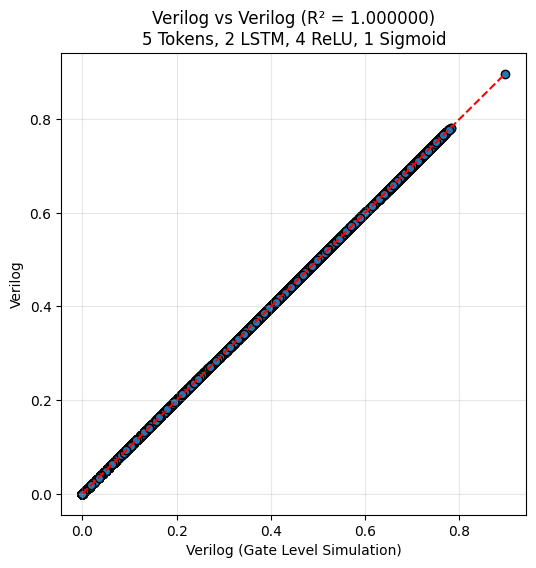

In [10]:

r2 = r2_score(verilog_gls, verilog[:num_gls])

plt.figure(figsize=(6, 6))

plt.scatter(
    verilog_gls,
    verilog[:num_gls],
    edgecolor='k'
)

# Linha ideal y = x
xmin = min(min(verilog_gls), min(verilog[:num_gls]))
xmax = max(max(verilog_gls), max(verilog[:num_gls]))

plt.plot(
    [xmin, xmax],
    [xmin, xmax],
    'r--'
)

plt.xlabel("Verilog (Gate Level Simulation)")
plt.ylabel("Verilog")

plt.title(
    f"Verilog vs Verilog (R² = {r2:.6f})\n"
    f"{architecture}"
)

plt.grid(True, alpha=0.3)

plt.show()
